# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
3. True or false, and explain: Logistic regression is a linear model.
4. True or false, and explain: Logistic regression cannot be used for classification.
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

**1.1** We use these models because they allow us to capture nonlinear relationships while still using a linear structure underneath. By applying an activation function (like the logistic function), we can model outcomes like probabilities that are bounded between 0 and 1. This makes them more flexible and appropriate for real-world data compared to simple linear models, which can produce unrealistic predictions.

**1.2** Binary and categorical cross entropy are effective because they measure how well predicted probabilities match the true outcomes. They heavily penalize confident but incorrect predictions, which encourages the model to produce accurate probability estimates. This aligns well with logistic regression, which is designed to model probabilities rather than raw values.

**1.3** True. Logistic regression is linear in the sense that it models a linear combination of the inputs. The nonlinearity comes from applying the logistic (sigmoid) function to that linear combination, not from the model itself.

**1.4** False. Logistic regression is commonly used for classification by converting predicted probabilities into class labels (e.g., using a threshold like 0.5). It is one of the most standard methods for binary classification.

**1.5** No, the coefficient does not represent a direct change in the predicted probability. Instead, it represents the change in the log-odds of the outcome for a one-unit increase in the feature. This makes interpretation less direct than in linear regression.

**1.6** False. Logistic regression is still a linear model in the features, so it cannot automatically capture complex relationships. Feature engineering (like interactions or nonlinear transformations) is still important to improve model performance.

**1.7** False. Logistic regression is better when the outcome is categorical or probabilistic, but OLS is more appropriate for continuous outcomes. Each model is suited for different types of problems, so one is not universally better than the other.

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


**2.1**

In [17]:
import pandas as pd

# Load (semicolon-separated)
df = pd.read_csv("data/data.csv", sep=';')

# Select relevant columns
cols = [
    'Debtor',
    'Tuition fees up to date',
    'Scholarship holder',
    'Age at enrollment',
    'Curricular units 1st sem (approved)',
    'Target'
]

df = df[cols]

# Handle missing values (simple approach: drop)
df = df.dropna()

# Create binary target
df['dropout'] = (df['Target'] == 'Dropout').astype(int)

df.head()

,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,Curricular units 1st sem (approved),Target,dropout
0,0,1,0,20,0,Dropout,1
1,0,0,0,19,6,Graduate,0
2,0,0,0,19,0,Dropout,1
3,0,1,0,20,6,Graduate,0
4,0,1,0,45,5,Graduate,0


**2.2**

In [18]:
from sklearn.linear_model import LogisticRegression


X = df[['Debtor','Tuition fees up to date','Scholarship holder','Age at enrollment']]
y = df['dropout']

logit = LogisticRegression(max_iter=1000)
logit.fit(X, y)

coeffs = pd.Series(logit.coef_[0], index=X.columns)
print(coeffs)

Debtor                     0.530625
Tuition fees up to date   -2.556542
Scholarship holder        -1.227442
Age at enrollment          0.049925
dtype: float64


Debtor and Age at enrollment have positive coefficients, so they are associated with a higher probability of dropping out. This means students with outstanding debt and older students are more likely to drop out. Tuition fees up to date and Scholarship holder both have negative coefficients, so they are associated with a lower dropout probability. Being up to date on tuition especially has a strong negative effect, suggesting it significantly reduces dropout risk.

**2.3**

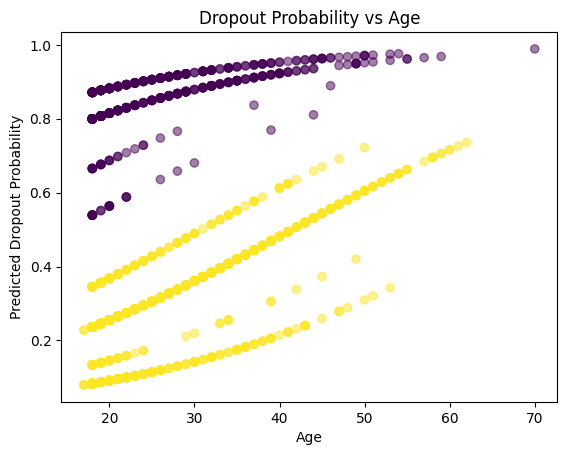

In [19]:
import matplotlib.pyplot as plt

# Get predicted probabilities
df['prob'] = logit.predict_proba(X)[:,1]

# Scatter plot
plt.figure()
plt.scatter(df['Age at enrollment'], df['prob'],
            c=df['Tuition fees up to date'], alpha=0.5)
plt.xlabel("Age")
plt.ylabel("Predicted Dropout Probability")
plt.title("Dropout Probability vs Age")
plt.show()

From the plot, being up to date on tuition consistently lowers the predicted probability of dropout across all ages. The gap between the two groups looks fairly constant, but it is slightly more noticeable at higher ages where dropout risk is already higher. On average, being up to date on tuition reduces the predicted probability of dropout by roughly 0.4 to 0.5, which is a pretty large effect.

**2.4**

In [20]:
from sklearn.metrics import confusion_matrix, accuracy_score

y_pred = logit.predict(X)

cm = confusion_matrix(y, y_pred)
acc = accuracy_score(y, y_pred)

print(cm)
print("Accuracy:", acc)

[[2841  162]
 [ 891  530]]
Accuracy: 0.7619801084990958


**2.5**

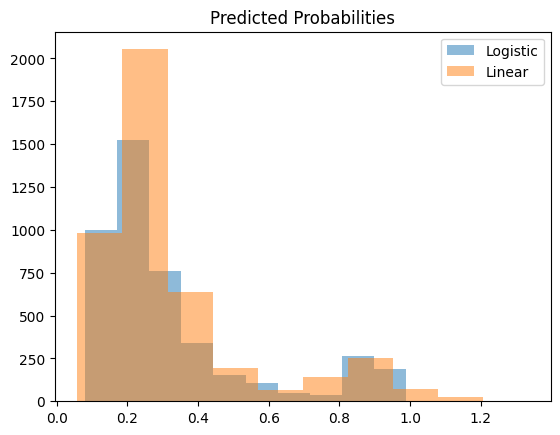

In [22]:
from sklearn.linear_model import LinearRegression

lin = LinearRegression()
lin.fit(X, y)

df['lin_prob'] = lin.predict(X)

plt.hist(df['prob'], alpha=0.5, label='Logistic')
plt.hist(df['lin_prob'], alpha=0.5, label='Linear')
plt.legend()
plt.title("Predicted Probabilities")
plt.show()

When comparing them, logistic regression gives probabilities between 0 and 1, while the linear model can give unrealistic values. Because of this, logistic regression performs better for predicting dropout.

**2.6**

Based on the model results, the students most at risk of dropping out are those who are not up to date on tuition, have outstanding debt, and are older at enrollment. The scatter plot shows that students who are not up to date on tuition consistently have much higher predicted dropout probabilities across all ages, often close to 1. In contrast, students who are up to date on tuition have significantly lower predicted probabilities. The difference between these groups is especially large for older students, where being up to date on tuition appears to reduce dropout risk the most. Overall, financial factors seem to be the strongest predictors of dropout. To help at-risk students stay enrolled, schools could provide financial assistance, flexible payment plans, or targeted support for students with debt. Academic advising and early intervention for struggling students could also help reduce dropout rates.

**2.7**

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

X_multi = df[['Debtor','Tuition fees up to date','Curricular units 1st sem (approved)']]
y_multi = df['Target']

multi = LogisticRegression(max_iter=1000)
multi.fit(X_multi, y_multi)

# Predictions
y_pred = multi.predict(X_multi)
print(confusion_matrix(y_multi, y_pred))

# Probabilities
probs = multi.predict_proba(X_multi)
print(probs[:5])

[[1054    0  367]
 [ 280    0  514]
 [ 146    0 2063]]
[[0.68054695 0.21046429 0.10898876]
 [0.69541412 0.1460432  0.15854268]
 [0.95298821 0.04119918 0.00581261]
 [0.11780804 0.1769832  0.70520876]
 [0.18422683 0.21266883 0.60310434]]


The multinomial logistic regression predicts the three classes, but the confusion matrix shows it performs better on more common categories and may not predict every class using .predict(). In contrast, .predict_proba() gives probabilities for all classes for every observation. This means the hard classification may miss some classes, while the probability predictions still account for all possible outcomes.

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics 
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class? 

**3.1**

In [27]:
import pandas as pd

df = pd.read_csv("data/cirrhosis.csv")

# Keep relevant columns
df = df[['Bilirubin','Edema','Drug','Stage','Status']]

# Drop missing values
df = df.dropna()

# Create binary survival (alive = 1, dead = 0)
df['alive'] = df['Status'].isin(['C','CL']).astype(int)

# Convert Edema to numeric (simple encoding)
df['Edema'] = df['Edema'].map({'N':0, 'S':1, 'Y':2})

# Convert Drug to binary
df['Drug'] = (df['Drug'] == 'D-penicillamine').astype(int)

df.head()

,Bilirubin,Edema,Drug,Stage,Status,alive
0,14.5,2,1,4.0,D,0
1,1.1,0,1,3.0,C,1
2,1.4,1,1,4.0,D,0
3,1.8,1,1,4.0,D,0
4,3.4,0,0,3.0,CL,1


The dataset was filtered to the relevant variables and missing values were removed. Status was converted into a binary variable where alive = 1 and dead = 0. Categorical variables such as Edema and Drug were converted into numeric form for modeling.

**3.2**

In [28]:
from sklearn.linear_model import LogisticRegression

X = df[['Edema','Drug','Bilirubin']]
y = df['alive']

logit = LogisticRegression(max_iter=1000)
logit.fit(X, y)

coeffs = pd.Series(logit.coef_[0], index=X.columns)
print(coeffs)

Edema       -0.915295
Drug        -0.223469
Bilirubin   -0.348584
dtype: float64


All coefficients are negative, meaning higher values of these variables decrease survival probability. The drug does not appear to improve survival since its coefficient is negative. Higher bilirubin strongly reduces survival, which makes sense since it reflects worse liver function. More severe edema is also associated with lower survival.

**3.3**

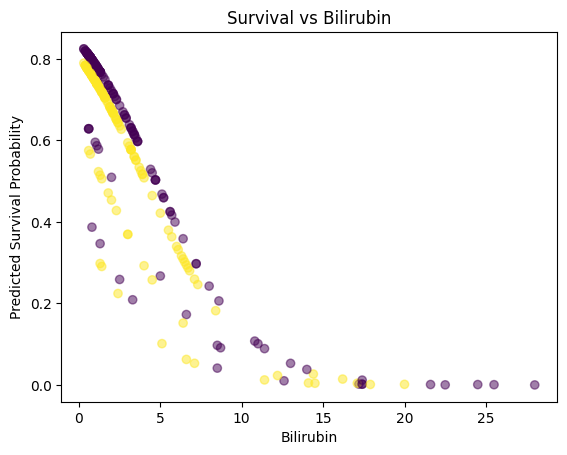

In [29]:
import matplotlib.pyplot as plt

df['prob'] = logit.predict_proba(X)[:,1]

plt.scatter(df['Bilirubin'], df['prob'], c=df['Drug'], alpha=0.5)
plt.xlabel("Bilirubin")
plt.ylabel("Predicted Survival Probability")
plt.title("Survival vs Bilirubin")
plt.show()

Survival probability decreases as bilirubin increases. From the plot, the drug does not clearly increase survival at any level of bilirubin, and if anything, survival looks slightly lower for patients taking the drug. Overall, bilirubin is the strongest driver of survival.

**3.4**

In [30]:
from sklearn.metrics import confusion_matrix, accuracy_score

y_pred = logit.predict(X)

print(confusion_matrix(y, y_pred))
print("Accuracy:", accuracy_score(y, y_pred))

[[ 60  65]
 [ 14 173]]
Accuracy: 0.7467948717948718


The model has an accuracy of about 0.75, meaning it correctly classifies survival outcomes most of the time. It performs reasonably well but still makes some errors, especially in distinguishing between survivors and non-survivors.

**3.5**

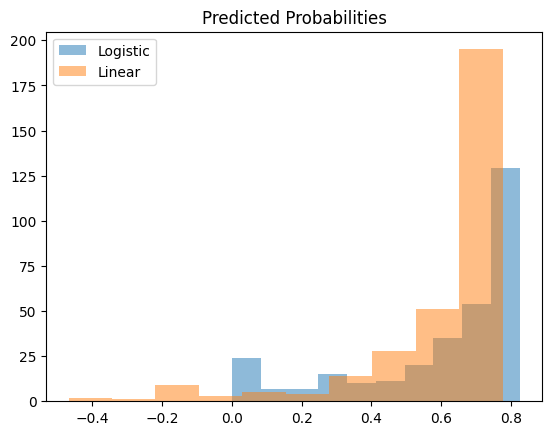

In [31]:
from sklearn.linear_model import LinearRegression

lin = LinearRegression()
lin.fit(X, y)

df['lin_prob'] = lin.predict(X)

plt.hist(df['prob'], alpha=0.5, label='Logistic')
plt.hist(df['lin_prob'], alpha=0.5, label='Linear')
plt.legend()
plt.title("Predicted Probabilities")
plt.show()

Logistic regression produces probabilities between 0 and 1, while the linear model gives unrealistic values (including negatives). Because of this, logistic regression performs better for predicting survival probabilities.

**3.6**

In [32]:
X_stage = df[['Edema','Bilirubin']]
y_stage = df['Stage']

multi = LogisticRegression(max_iter=1000)
multi.fit(X_stage, y_stage)

y_pred_stage = multi.predict(X_stage)

from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_stage, y_pred_stage))

[[  0   0  16   0]
 [  0   0  61   6]
 [  0   0 102  18]
 [  0   0  74  35]]


The model struggles to predict all stages correctly and mainly predicts a few categories. Some stages are not predicted at all using .predict(), which suggests the model is biased toward more common classes. However, .predict_proba() still provides probabilities for all stages, even if they are not selected in the final prediction.

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio? 

**4.1**

The prediction is  
$$
\hat{y} = b_0 + \sum_{k=1}^{K} b_k x_k.
$$

Taking the derivative with respect to $x_k$:  
$$
\frac{\partial \hat{y}}{\partial x_k} = b_k.
$$

So basically, a one-unit increase in $x_k$ changes the prediction by exactly $b_k$. This makes the coefficients really easy to interpret since they directly tell you how much the prediction changes.



**4.2**

The prediction is  
$$
\hat{p} = \frac{e^{b \cdot x}}{1 + e^{b \cdot x}}.
$$

Taking the derivative with respect to $x_k$:  
$$
\frac{\partial \hat{p}}{\partial x_k} = \hat{p}(1 - \hat{p}) \cdot b_k.
$$

Unlike the linear model, the effect of $x_k$ depends on the value of $\hat{p}$, so it’s not constant.

The effect is biggest when $\hat{p} \approx 0.5$, since $\hat{p}(1-\hat{p})$ is largest there. Around that point, the effect is roughly  
$$
\frac{1}{4} b_k,
$$
so the coefficient is kind of a scaled version of the true effect.

**4.3**

We can rewrite the model as  
$$
\log\left(\frac{\hat{p}}{1 - \hat{p}}\right) = b \cdot x.
$$

Taking the derivative with respect to $x_k$:  
$$
\frac{\partial}{\partial x_k} \log\left(\frac{\hat{p}}{1 - \hat{p}}\right) = b_k.
$$

So here, a one-unit increase in $x_k$ changes the log-odds by exactly $b_k$. This is why logistic regression coefficients are usually interpreted in terms of log-odds.